# Report part 1 — Model Evaluation + Demo Runner

## What this notebook does
1) Loads split + metadata artifacts created by your EDA notebook (`metadata.csv`, `train_ids.npy`, `val_ids.npy`, `test_ids.npy`)
2) Loads:
   - Model A checkpoint: `A_effb4_full_hires448_best.pt`
   - Model B checkpoint: `B_self_guided_GAP_best.pt`
3) Evaluates both models on **VAL** and **TEST**
4) Saves:
   - Metrics JSON
   - Predictions CSV
   - Confusion matrix NPY + PNG


**NOTE** Only run this notebook for part 1 the other notebooks were used to train models and have extremely long run times or are broken due to to pathing issue from switching paths while submission.

# Short Report

## Data

The images from the data were split according to the provided split and then further split into train/ val using a 90-10 split ratio. The split was done using stratified splitting so that every class is contained within each of the train and val datasets.

The image size may wary in training as to refine the model there were attempts to increase the size to 384px and 448px as well but for the majority of the training the size was set it 224px and normalised using standard ImageNet statistics.

I decided not to use the provided bounding box during training for the most part as when I was trying to train with the bounding boxes it was consistently performing worse compared to the full images. This is potentially because of the more contextual information available in the full images.

## Model A (EfficientNet B4)

Model A is bult on the pretraned EfficientNet-B4 architecture and then fine-tuned for the specific purposes of this assignment. The transfer learning paradigm is followed in this approach where features learnt from large-scale image datasets (Imagenetv1 in this case) were adapted to the CUB dataset that was provided. This allows the model to learn discriminative bird features efficiently.

The design and training was informed by prior work showcasing the effectiveness of efficientnet as the backbone in fine-grained classification [1] and the advantage of transfer learning and feature extraction for bird classification [2].

Looking at the confusion matrix below, it is clear that the errors are present in a few specific classes which result in confusion due the similarity of the bird's features rather than being widespread across the classes.

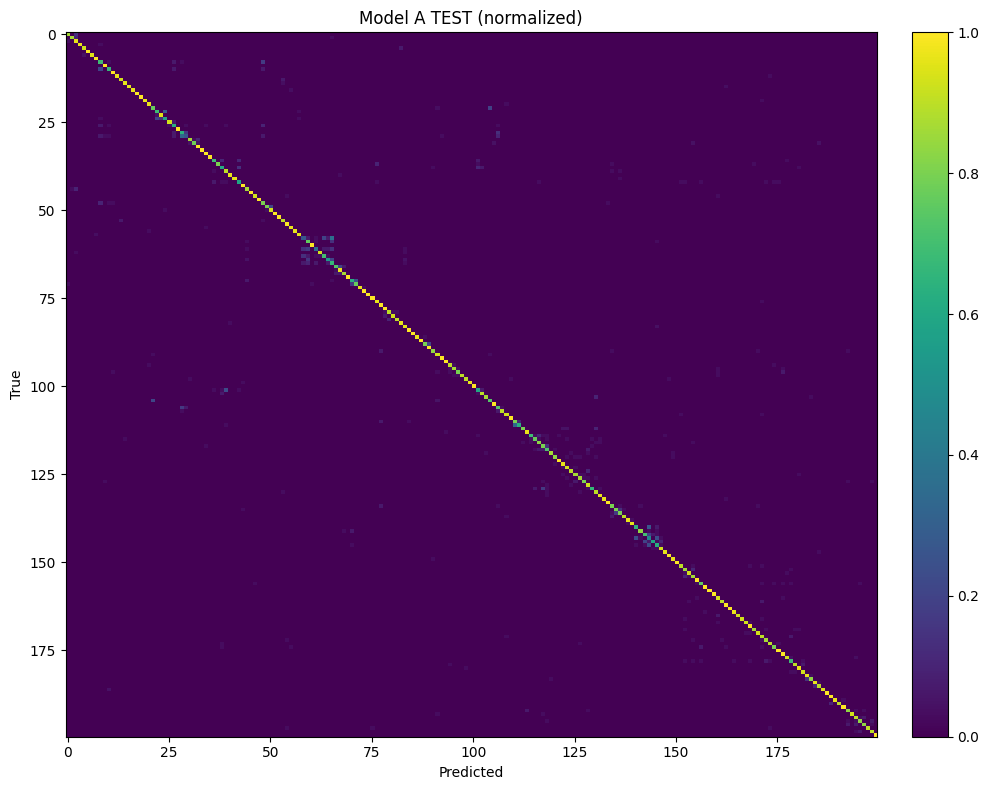

**Figure 3** shows the confusion matrix of Model A

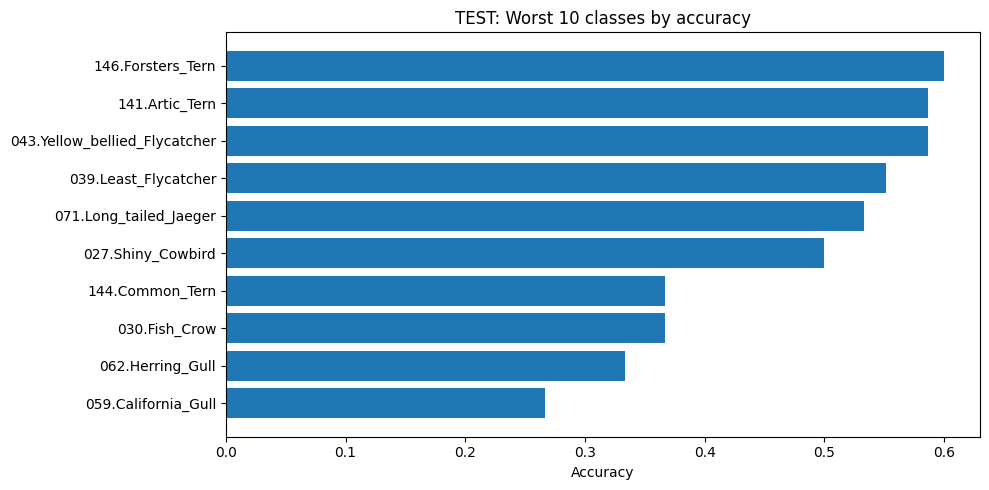

**Figure 2** visualises the most prominent off-diagonal confusions that model A exhibited.

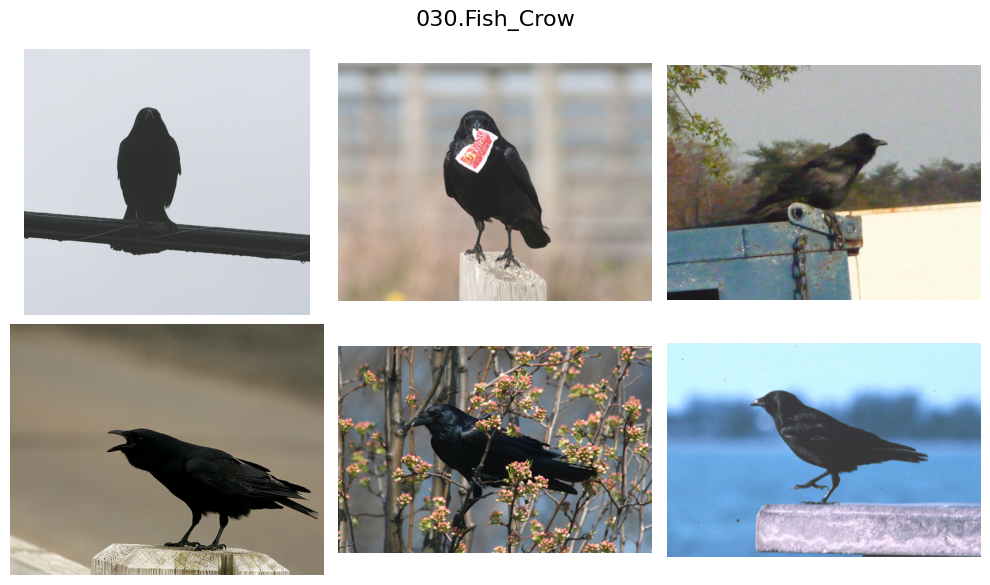

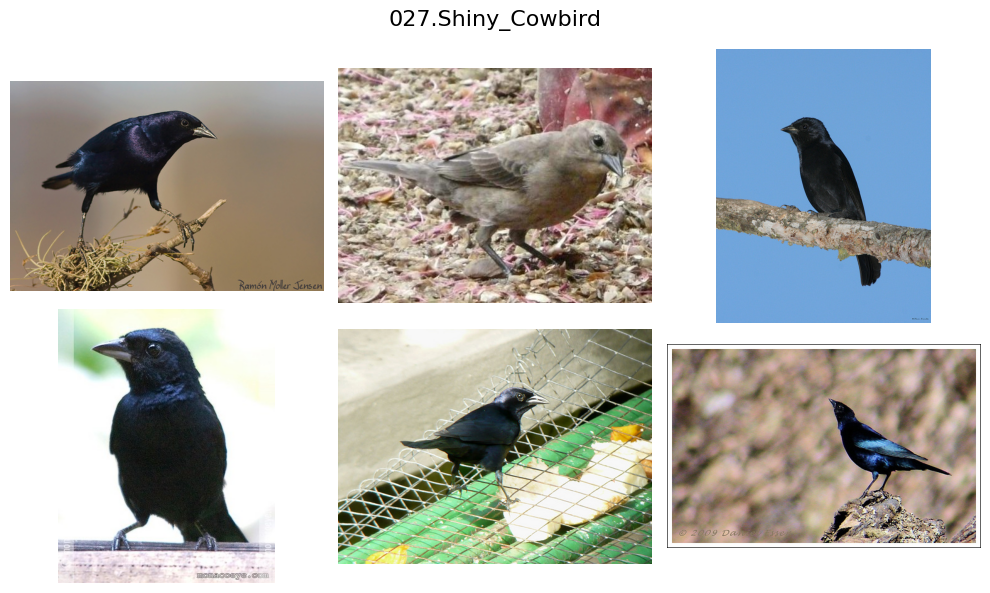

**Figure 3** shows the birds that the model struggles to classify properly. Possibly due to the similarity of their defining characterstics such as their jet black feathers and similar beaks and feet.

The final model achieved 88.13% test accuracy, with macro precision 0.885, recall 0.882, and F1-score 0.881, with similar validation performance (88.67% accuracy), indicating stable generalisation. Analysis of the confusion matrix shows that most errors occur between visually similar bird species with overlapping colour patterns or morphology.

## Model B (Custom Model)

Standard augmentations (random resized crop and horizontal flip) were applied to improve generalisation. Inspired by prior work on fine-grained image recognition that uses internal feature activations to localise discriminative object regions, a self-guided attention mechanism was incorporated into training [3]. After initial warm-up. feature-map activations were used in order to generate attention maps that guided two additional training views:
- An attention crop focusing on discriminating regions
- An attention drop masking dominant regions
This makes the model learn complementary fine-grained features across the object instead of relying on a single region. [3]

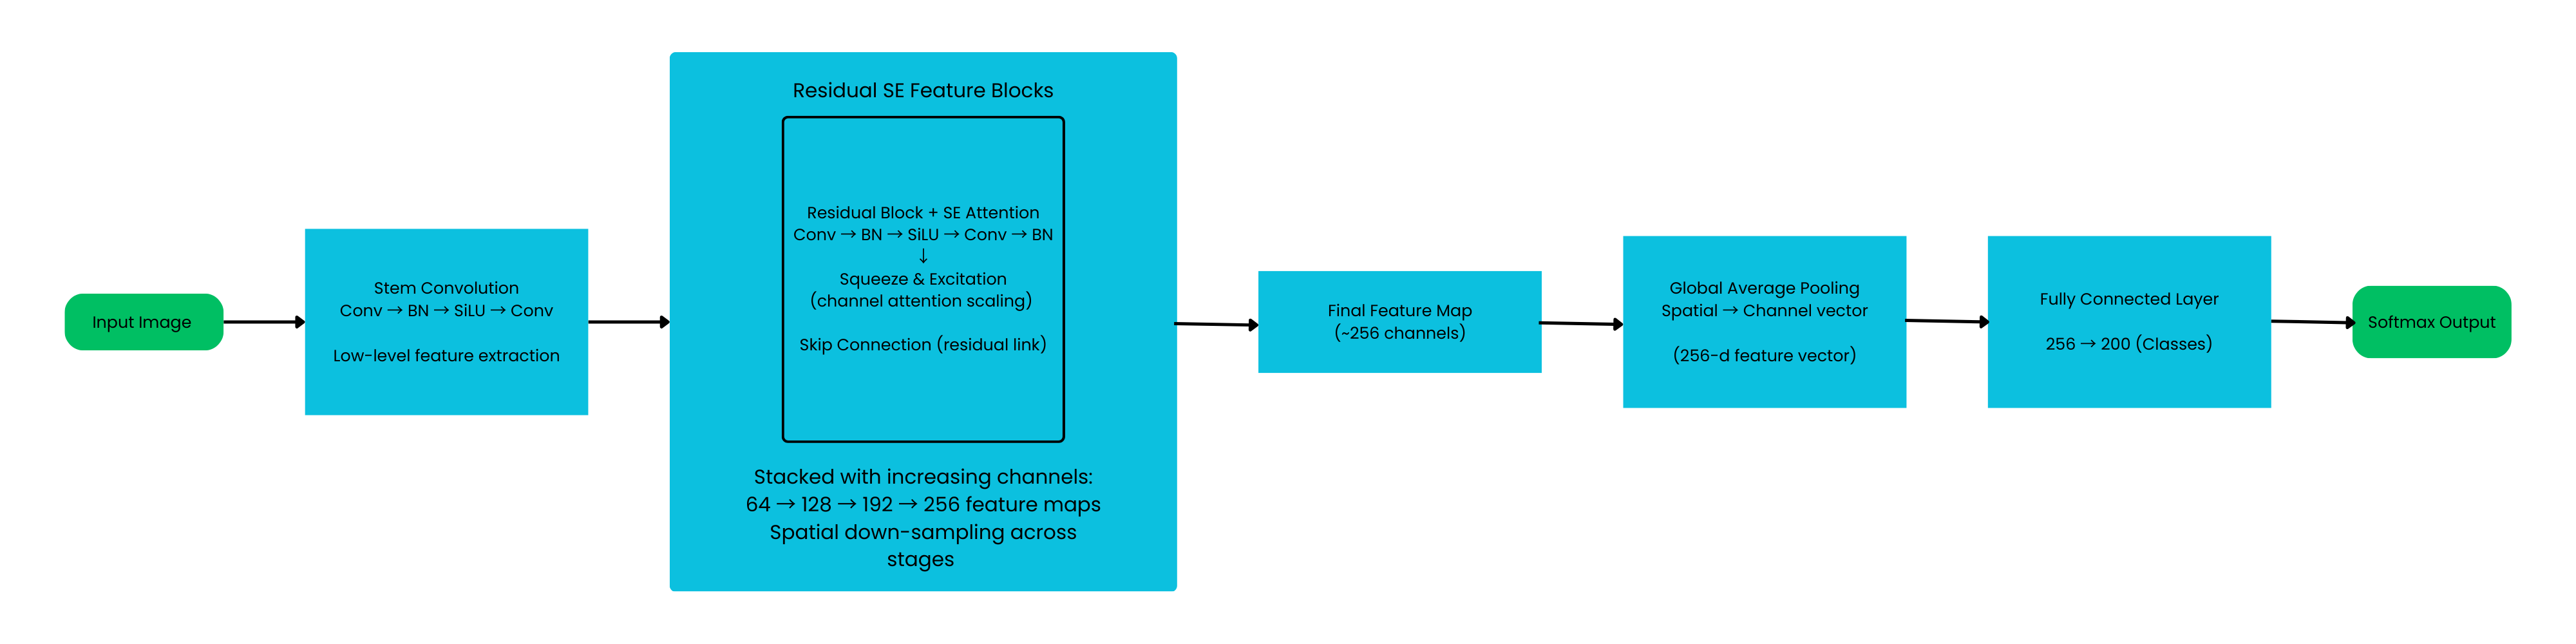

**Figure 4** shows the architecture of the custom model (model B)

The final hyperparameter configuration of the model is as follows:
| Hyperparameter     | Value                  |
|--------------------|------------------------|
| Optimizer          | AdamW                  |
| LR schedule        | Cosine decay + warmup  |
| Learning rate      | 3e-4                   |
| Batch size         | 128                    |
| Weight decay       | 0.05                   |
| Label smoothing    | 0.1                    |
| Grad clipping      | Enabled                |
| Loss               | Cross-entropy          |

This was reached through sheer trial and error and referenced from paper by Edwin et al [3].

The final model achieved 42.18% test accuracy, with macro precision 0.425, recall 0.424, and F1-score 0.418. The confusion matrix indicated that most misclassifications occur between visually similar bird species, this speaks to the difficulty of training a model to classify fine-grained images of birds from scratch.

# References

[1] C.-Y. Ngo, L.-Y. Chong, S.-C. Chong, and P.-Y. Goh, “Bird species recognition system with fine-tuned model,” International Journal on Advanced Science, Engineering and Information Technology, vol. 13, no. 5, pp. 1719–1724, 2023.

[2] P. Wu, G. Wu, X. Wu, X. Yi, and N. X. Xiong, “Birds classification based on deep transfer learning,” in Proc. IEEE Int. Conf. Smart Internet of Things (SmartCom), 2020, pp. 173–183.

[3] E. A. Rios, F. Mikael, O. Gosal, F. Oyerinde, H.-C. Liang, B.-C. Lai, and M.-C. Hu, “Fine-grained image recognition from scratch with teacher-guided data augmentation,” arXiv preprint arXiv:2507.12157, 2025.

# Imports and Reproducibility

In [4]:
import os
import re
import gc
import json
import time
import math
import random
from dataclasses import dataclass
from pathlib import Path
from typing import Optional, Tuple, List, Dict

import numpy as np
import pandas as pd

from PIL import Image, ImageFile

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import timm
from timm.data import resolve_data_config, create_transform

import torchvision.transforms as T
from torchvision.transforms import InterpolationMode

import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

from tqdm.auto import tqdm

In [5]:
!pip -q install timm==1.* scikit-learn==1.* pandas==2.* matplotlib==3.* tqdm==4.* pillow==10.* torchvision


In [6]:
IN_COLAB = True
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    if not Path("/content/drive").exists():
        drive.mount("/content/drive")

if IN_COLAB:
    NOTEBOOK_DIR = Path("/content/drive/MyDrive/Deep Learning Assignment Final/Part 1")
else:
    # Local fallback: run from wherever, but we default to cwd
    NOTEBOOK_DIR = Path.cwd()

CKPT_DIR = NOTEBOOK_DIR / "_checkpoints"
ART_DIR  = NOTEBOOK_DIR / "_artifacts"

CKPT_DIR.mkdir(parents=True, exist_ok=True)
ART_DIR.mkdir(parents=True, exist_ok=True)

print("IN_COLAB     :", IN_COLAB)
print("NOTEBOOK_DIR :", NOTEBOOK_DIR)
print("CKPT_DIR     :", CKPT_DIR)
print("ART_DIR      :", ART_DIR)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Mounted at /content/drive
IN_COLAB     : True
NOTEBOOK_DIR : /content/drive/MyDrive/Deep Learning Assignment Final/Part 1
CKPT_DIR     : /content/drive/MyDrive/Deep Learning Assignment Final/Part 1/_checkpoints
ART_DIR      : /content/drive/MyDrive/Deep Learning Assignment Final/Part 1/_artifacts
Device: cuda


In [7]:
SEED = 1729

def set_global_seed(seed: int = 42, deterministic: bool = True) -> None:
    """
    Sets random seeds for Python/NumPy/PyTorch.
    deterministic=True is safer for reproducible eval (may reduce speed).
    """
    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

        # cuBLAS determinism (best effort)
        os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
        try:
            torch.use_deterministic_algorithms(True)
        except Exception as e:
            print("Warning: Could not fully enforce deterministic algorithms:", e)

set_global_seed(SEED, deterministic=True)
print("Seed set to:", SEED)

Seed set to: 1729


# Loading Checkpoints and Artifacts

In [8]:
MODEL_A_NAME = "A_effb4_full_hires448_best.pt"
MODEL_B_NAME = "B_self_guided_GAP_best.pt"

CKPT_A = CKPT_DIR / MODEL_A_NAME
CKPT_B = CKPT_DIR / MODEL_B_NAME

if not CKPT_A.exists():
    raise FileNotFoundError(f"Missing Model A checkpoint: {CKPT_A}")
if not CKPT_B.exists():
    raise FileNotFoundError(f"Missing Model B checkpoint: {CKPT_B}")

print("Using Model A:", CKPT_A.name)
print("Using Model B:", CKPT_B.name)

Using Model A: A_effb4_full_hires448_best.pt
Using Model B: B_self_guided_GAP_best.pt


In [9]:
def list_checkpoints(folder: Path) -> List[Path]:
    return sorted(list(folder.glob("*.pt")) + list(folder.glob("*.pth")))

In [10]:
def try_read_ckpt_metadata(path: Path) -> Dict:
    """
    Reads checkpoint dict if possible. Some checkpoints may be raw state_dict.
    """
    try:
        obj = torch.load(path, map_location="cpu")
        if isinstance(obj, dict):
            return obj
    except Exception:
        pass
    return {}

In [11]:
def guess_model_family(filename: str, meta: Dict) -> str:
    """
    Best-effort separation for printing only.
    Actual selection is manual (MODEL_A_NAME/MODEL_B_NAME).
    """
    name = filename.lower()
    if "model_name" in meta:
        return "A"
    if meta.get("arch") is not None:
        return "B"
    if name.startswith("a_") or "eff" in name or "efficient" in name:
        return "A"
    if name.startswith("b_") or "self_guided" in name or "fgresse" in name or "gap" in name:
        return "B"
    return "?"

In [12]:
paths = list_checkpoints(CKPT_DIR)
if not paths:
    raise FileNotFoundError(f"No checkpoints found in: {CKPT_DIR}")

A_ckpts, B_ckpts, U_ckpts = [], [], []

for p in paths:
    meta = try_read_ckpt_metadata(p)
    fam = guess_model_family(p.name, meta)
    row = {
        "file": p.name,
        "val_acc": meta.get("val_acc"),
        "img_size": meta.get("img_size"),
        "model_name": meta.get("model_name"),
        "arch": meta.get("arch"),
    }
    if fam == "A":
        A_ckpts.append(row)
    elif fam == "B":
        B_ckpts.append(row)
    else:
        U_ckpts.append(row)

print("\n===== Model A candidates =====")
if A_ckpts:
    for r in A_ckpts:
        print(f"- {r['file']} | val_acc={r['val_acc']} | img_size={r['img_size']} | model_name={r['model_name']}")
else:
    print("(none detected)")

print("\n===== Model B candidates =====")
if B_ckpts:
    for r in B_ckpts:
        print(f"- {r['file']} | val_acc={r['val_acc']} | img_size={r['img_size']} | arch={r['arch']}")
else:
    print("(none detected)")

if U_ckpts:
    print("\n===== Unknown / unclassified =====")
    for r in U_ckpts:
        print(f"- {r['file']} | val_acc={r['val_acc']}")


===== Model A candidates =====
- A_convnext_base_384_full_best.pt | val_acc=0.025 | img_size=384 | model_name=convnext_base
- A_effb4_full_LONG_best.pt | val_acc=0.5566666666666666 | img_size=380 | model_name=tf_efficientnet_b4
- A_effb4_full_LONG_best_2.pt | val_acc=0.88 | img_size=380 | model_name=tf_efficientnet_b4
- A_effb4_full_LONG_plus30_best.pt | val_acc=0.8583333333333333 | img_size=380 | model_name=tf_efficientnet_b4
- A_effb4_full_hires448_best.pt | val_acc=0.8866666666666667 | img_size=448 | model_name=tf_efficientnet_b4
- A_effb4_full_resume0855_best.pt | val_acc=0.88 | img_size=380 | model_name=tf_efficientnet_b4
- A_effb4_full_resume088_polish_best.pt | val_acc=0.8866666666666667 | img_size=380 | model_name=tf_efficientnet_b4
- A_tf_efficientnet_b4_380_bbox_best.pt | val_acc=0.8083333333333333 | img_size=380 | model_name=tf_efficientnet_b4
- A_tf_efficientnet_b4_380_full_HS_best.pt | val_acc=0.7433333333333333 | img_size=380 | model_name=tf_efficientnet_b4
- A_tf_effici

In [13]:
def find_eda_artifacts_dir(part1_art_dir: Path) -> Path:
    """
    Preferred: Part 1/_artifacts (this notebook folder)
    Fallback: /content/drive/MyDrive/CUB_200_2011/_artifacts
    """
    required = ["metadata.csv", "train_ids.npy", "val_ids.npy", "test_ids.npy"]
    if all((part1_art_dir / f).exists() for f in required):
        return part1_art_dir

    # Fallback to the EDA default used in your provided EDA notebook
    if IN_COLAB:
        cub_fallback = Path("/content/drive/MyDrive/CUB_200_2011/_artifacts")
        if all((cub_fallback / f).exists() for f in required):
            return cub_fallback

    raise FileNotFoundError(
        "Could not find EDA artifacts.\n"
        "Expected in Part 1/_artifacts OR in MyDrive/CUB_200_2011/_artifacts:\n"
        "- metadata.csv\n- train_ids.npy\n- val_ids.npy\n- test_ids.npy"
    )

In [14]:
EDA_ART_DIR = find_eda_artifacts_dir(ART_DIR)
print("Using EDA artifacts from:", EDA_ART_DIR)

df_meta = pd.read_csv(EDA_ART_DIR / "metadata.csv")
train_ids = np.load(EDA_ART_DIR / "train_ids.npy")
val_ids   = np.load(EDA_ART_DIR / "val_ids.npy")
test_ids  = np.load(EDA_ART_DIR / "test_ids.npy")

# Build split frames
train_df = df_meta[df_meta["image_id"].isin(train_ids)].copy()
val_df   = df_meta[df_meta["image_id"].isin(val_ids)].copy()
test_df  = df_meta[df_meta["image_id"].isin(test_ids)].copy()

# Determine label base (EDA uses class_id as 1..200)
class_id_min = int(df_meta["class_id"].min())
class_id_max = int(df_meta["class_id"].max())
if (class_id_min, class_id_max) == (1, 200):
    label_offset = 1
elif (class_id_min, class_id_max) == (0, 199):
    label_offset = 0
else:
    raise ValueError(f"Unexpected class_id range: min={class_id_min}, max={class_id_max}")

NUM_CLASSES = 200
print("Splits:", {"train": len(train_df), "val": len(val_df), "test": len(test_df)})
print("class_id range:", (class_id_min, class_id_max), "| label_offset:", label_offset)

# Optional class name mapping for nicer outputs
if "class_name" in df_meta.columns:
    tmp = df_meta[["class_id", "class_name"]].drop_duplicates()
    tmp["class_index"] = tmp["class_id"].astype(int) - label_offset
    class_index_to_name = dict(zip(tmp["class_index"], tmp["class_name"]))
else:
    class_index_to_name = {i: str(i) for i in range(NUM_CLASSES)}

Using EDA artifacts from: /content/drive/MyDrive/Deep Learning Assignment Final/Part 1/_artifacts
Splits: {'train': 5394, 'val': 600, 'test': 5794}
class_id range: (1, 200) | label_offset: 1


# Helper Functions


In [15]:
def now_tag(prefix: str) -> str:
    return f"{prefix}_{time.strftime('%Y%m%d-%H%M%S')}"

In [16]:
def write_json(path: Path, payload: Dict) -> None:
    with open(path, "w") as f:
        json.dump(payload, f, indent=2)

In [17]:
def save_confusion_matrix_plot(cm: np.ndarray, title: str, out_png: Path, normalize: bool = True) -> None:
    cm = cm.astype(np.float64)
    if normalize:
        denom = cm.sum(axis=1, keepdims=True)
        denom[denom == 0] = 1
        cm = cm / denom

    plt.figure(figsize=(10, 8))
    im = plt.imshow(cm, interpolation="nearest", aspect="auto")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.savefig(out_png, dpi=250)
    plt.show()

In [18]:
def compute_basic_metrics(y_true: np.ndarray, y_pred: np.ndarray, num_classes: int) -> Dict:
    acc  = float(accuracy_score(y_true, y_pred))
    prec = float(precision_score(y_true, y_pred, average="macro", zero_division=0))
    rec  = float(recall_score(y_true, y_pred, average="macro", zero_division=0))
    f1   = float(f1_score(y_true, y_pred, average="macro", zero_division=0))
    cm   = confusion_matrix(y_true, y_pred, labels=np.arange(num_classes))
    return {
        "accuracy": acc,
        "precision_macro": prec,
        "recall_macro": rec,
        "f1_macro": f1,
        "confusion_matrix": cm,
    }

In [19]:
def print_metrics_block(title: str, m: Dict) -> None:
    print(f"\n=== {title} ===")
    print(f"Accuracy         : {m['accuracy']:.4f}")
    print(f"Precision (macro): {m['precision_macro']:.4f}")
    print(f"Recall (macro)   : {m['recall_macro']:.4f}")
    print(f"F1 (macro)       : {m['f1_macro']:.4f}")

# Load Dataset

In [20]:
class CubEvalDatasetFullOrBbox(Dataset):
    """
    Dataset used by both models.
    - Uses metadata.csv columns: abs_path, class_id, bbox (x,y,w,h)
    - crop_mode:
        "full" -> no bbox crop
        "bbox" -> crop to bbox with padding
    """
    def __init__(self, frame: pd.DataFrame, transform, crop_mode: str = "full", bbox_pad_frac: float = 0.08):
        self.frame = frame.reset_index(drop=True)
        self.transform = transform
        self.crop_mode = crop_mode
        self.bbox_pad_frac = float(bbox_pad_frac)
        if crop_mode not in {"full", "bbox"}:
            raise ValueError("crop_mode must be 'full' or 'bbox'")

    def __len__(self) -> int:
        return len(self.frame)

    def __getitem__(self, idx: int):
        r = self.frame.iloc[idx]
        img = Image.open(r["abs_path"]).convert("RGB")

        if self.crop_mode == "bbox":
            # bbox is in original image pixel space
            x, y, w, h = float(r["x"]), float(r["y"]), float(r["w"]), float(r["h"])
            pad_w = self.bbox_pad_frac * w
            pad_h = self.bbox_pad_frac * h

            left   = max(0, int(x - pad_w))
            top    = max(0, int(y - pad_h))
            right  = min(img.width,  int(x + w + pad_w))
            bottom = min(img.height, int(y + h + pad_h))

            img = img.crop((left, top, right, bottom))

        x = self.transform(img)
        y = int(r["class_id"]) - label_offset  # convert to 0..199
        image_id = int(r["image_id"])
        return x, y, image_id

# Model A

In [21]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

def normalize_imagenet_batch(x: torch.Tensor) -> torch.Tensor:
    mean = x.new_tensor(IMAGENET_MEAN).view(1, 3, 1, 1)
    std  = x.new_tensor(IMAGENET_STD).view(1, 3, 1, 1)
    return (x - mean) / std

def make_model_b_eval_transform(img_size: int) -> T.Compose:
    # Resize 1.14x then center-crop, bicubic, ToTensor (0..1)
    return T.Compose([
        T.Resize(int(img_size * 1.14), interpolation=InterpolationMode.BICUBIC),
        T.CenterCrop(img_size),
        T.ToTensor(),
    ])

In [22]:
def load_checkpoint_dict(path: Path) -> Dict:
    obj = torch.load(path, map_location="cpu")
    if isinstance(obj, dict) and "model" in obj:
        return obj
    if isinstance(obj, dict):
        # treat as raw state_dict
        return {"model": obj}
    raise ValueError(f"Unsupported checkpoint format: {path}")

In [23]:
def build_model_a_and_load_weights(ckpt_path: Path, num_classes: int) -> Tuple[nn.Module, Dict]:
    ckpt = load_checkpoint_dict(ckpt_path)

    model_name = ckpt.get("model_name", "tf_efficientnet_b4")

    model = timm.create_model(model_name, pretrained=False, num_classes=num_classes)
    model.load_state_dict(ckpt["model"], strict=True)
    model.to(device).eval()

    return model, ckpt

# Model B

In [24]:
class SqueezeExcite(nn.Module):
    def __init__(self, channels: int, reduction: int = 16):
        super().__init__()
        hidden = max(8, channels // reduction)
        self.fc1 = nn.Conv2d(channels, hidden, 1, bias=True)
        self.fc2 = nn.Conv2d(hidden, channels, 1, bias=True)

    def forward(self, x):
        s = F.adaptive_avg_pool2d(x, 1)
        s = F.silu(self.fc1(s))
        s = torch.sigmoid(self.fc2(s))
        return x * s

In [25]:
class DropPath(nn.Module):
    def __init__(self, p: float = 0.0):
        super().__init__()
        self.p = float(p)

    def forward(self, x):
        if (not self.training) or self.p == 0.0:
            return x
        keep = 1.0 - self.p
        shape = (x.shape[0],) + (1,) * (x.ndim - 1)
        mask = (torch.rand(shape, device=x.device) < keep).to(x.dtype)
        return x * mask / keep

In [26]:
class ResSEBlock(nn.Module):
    def __init__(self, in_ch: int, out_ch: int, stride: int = 1, drop_path: float = 0.0):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_ch)
        self.se    = SqueezeExcite(out_ch)
        self.dp    = DropPath(drop_path)

        self.proj = None
        if stride != 1 or in_ch != out_ch:
            self.proj = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch)
            )

    def forward(self, x):
        identity = x
        out = F.silu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = self.se(out)
        if self.proj is not None:
            identity = self.proj(identity)
        out = identity + self.dp(out)
        return F.silu(out)

In [27]:
class AttnPoolHead(nn.Module):
    def __init__(self, in_ch: int, num_classes: int, dropout: float = 0.3):
        super().__init__()
        self.attn = nn.Conv2d(in_ch, 1, 1, bias=True)
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(in_ch, num_classes)

    def forward(self, feat):
        a = self.attn(feat).flatten(2)          # [B,1,HW]
        a = torch.softmax(a, dim=-1)
        f = feat.flatten(2)                      # [B,C,HW]
        pooled = (f * a).sum(dim=-1)             # [B,C]
        pooled = self.drop(pooled)
        return self.fc(pooled)

In [28]:
class GAPHead(nn.Module):
    def __init__(self, in_ch: int, num_classes: int, dropout: float = 0.2):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(in_ch, num_classes)

    def forward(self, feat):
        x = self.pool(feat).flatten(1)
        x = self.drop(x)
        return self.fc(x)

In [29]:
class FGResSE(nn.Module):
    def __init__(
        self,
        num_classes: int = 200,
        widths=(64, 128, 192, 256),
        blocks=(2, 2, 3, 2),
        drop_path_rate: float = 0.10,
        head_dropout: float = 0.30,
    ):
        super().__init__()
        self.widths = tuple(widths)
        self.blocks = tuple(blocks)

        self.stem = nn.Sequential(
            nn.Conv2d(3, widths[0], 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(widths[0]),
            nn.SiLU(),
            nn.Conv2d(widths[0], widths[0], 3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(widths[0]),
            nn.SiLU(),
        )

        total = sum(blocks)
        dp_vals = torch.linspace(0, drop_path_rate, total).tolist()
        dp_i = 0

        stages = []
        in_ch = widths[0]
        for si, (out_ch, nblk) in enumerate(zip(widths, blocks)):
            for bi in range(nblk):
                stride = 2 if (si > 0 and bi == 0) else 1
                stages.append(ResSEBlock(in_ch, out_ch, stride=stride, drop_path=dp_vals[dp_i]))
                dp_i += 1
                in_ch = out_ch

        self.body = nn.Sequential(*stages)
        self.head = AttnPoolHead(in_ch, num_classes, dropout=head_dropout)

        self._init()

    def _init(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, std=0.02)
                nn.init.zeros_(m.bias)

    def forward(self, x, return_feat: bool = False):
        x = self.stem(x)
        feat = self.body(x)
        logits = self.head(feat)
        if return_feat:
            return logits, feat
        return logits

In [30]:
class FGResSE_GAP(FGResSE):
    def __init__(self, num_classes: int = 200, head_dropout: float = 0.2, drop_path_rate: float = 0.08, **kwargs):
        super().__init__(num_classes=num_classes, drop_path_rate=drop_path_rate, head_dropout=0.0, **kwargs)
        LAST_CH = 256
        self.head = GAPHead(LAST_CH, num_classes, dropout=head_dropout)

    def forward(self, x, return_feat: bool = False):
        x = self.stem(x)
        feat = self.body(x)
        logits = self.head(feat)
        if return_feat:
            return logits, feat
        return logits

In [31]:
def build_model_b_and_load_weights(ckpt_path: Path, num_classes: int) -> Tuple[nn.Module, Dict]:
    ckpt = load_checkpoint_dict(ckpt_path)

    model = FGResSE_GAP(num_classes=num_classes, head_dropout=0.2, drop_path_rate=0.08)
    model.load_state_dict(ckpt["model"], strict=True)  # strict should work with correct architecture
    model.to(device).eval()

    return model, ckpt

# Loaders

In [32]:
def make_model_a_eval_transform(model_name: str, img_size: int):
    """
    Uses timm's resolved config to match the way timm expects eval preprocessing.
    """
    dummy = timm.create_model(model_name, pretrained=False, num_classes=NUM_CLASSES).to(device)
    cfg = resolve_data_config({"input_size": (3, img_size, img_size)}, model=dummy)
    del dummy
    torch.cuda.empty_cache()
    return create_transform(**cfg, is_training=False)

In [33]:
def make_loader(frame: pd.DataFrame, transform, crop_mode: str, batch_size: int, num_workers: int = 2) -> DataLoader:
    ds = CubEvalDatasetFullOrBbox(frame, transform, crop_mode=crop_mode, bbox_pad_frac=0.08)
    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available(),
    )

# Inference Loops

In [34]:
@torch.no_grad()
def run_eval_model_a(model: nn.Module, loader: DataLoader) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Model A expects inputs already normalized by timm transform.
    """
    model.eval()
    all_true, all_pred, all_ids = [], [], []

    for x, y, image_id in tqdm(loader, desc="Eval Model A", leave=False):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
            logits = model(x)

        pred = logits.argmax(dim=1)

        all_true.append(y.cpu().numpy())
        all_pred.append(pred.cpu().numpy())
        all_ids.append(image_id.cpu().numpy())

    return np.concatenate(all_true), np.concatenate(all_pred), np.concatenate(all_ids)

In [35]:
@torch.no_grad()
def run_eval_model_b(model: nn.Module, loader: DataLoader) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Model B pipeline matches your notebook:
    - transform gives [0..1] tensor
    - normalize in batch to ImageNet mean/std
    """
    model.eval()
    all_true, all_pred, all_ids = [], [], []

    for x01, y, image_id in tqdm(loader, desc="Eval Model B", leave=False):
        x01 = x01.to(device, non_blocking=True)
        y   = y.to(device, non_blocking=True)

        x = normalize_imagenet_batch(x01)

        with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
            logits = model(x)

        pred = logits.argmax(dim=1)

        all_true.append(y.cpu().numpy())
        all_pred.append(pred.cpu().numpy())
        all_ids.append(image_id.cpu().numpy())

    return np.concatenate(all_true), np.concatenate(all_pred), np.concatenate(all_ids)

In [36]:
gc.collect()
torch.cuda.empty_cache()

model_a, ckptA = build_model_a_and_load_weights(CKPT_A, NUM_CLASSES)
model_b, ckptB = build_model_b_and_load_weights(CKPT_B, NUM_CLASSES)

print("Model A ckpt keys:", [k for k in ckptA.keys() if k != "model"][:10])
print("Model B ckpt keys:", [k for k in ckptB.keys() if k != "model"][:10])

print("Model A model_name:", ckptA.get("model_name", "tf_efficientnet_b4"))
print("Model A img_size  :", ckptA.get("img_size", 448), "(fallback to 448 for your file name)")
print("Model A crop_mode :", ckptA.get("crop_mode", "full"))

print("Model B img_size  :", ckptB.get("img_size", 224))
print("Model B crop_mode :", ckptB.get("crop_mode", "full"))

Model A ckpt keys: ['seed', 'val_acc', 'model_name', 'img_size', 'crop_mode', 'batch_size', 'lr', 'weight_decay', 'label_smoothing', 'resume_from']
Model B ckpt keys: ['val_acc', 'epoch', 'img_size', 'crop_mode', 'arch', 'from_scratch', 'use_crop', 'use_drop', 'crop_thr', 'crop_pad']
Model A model_name: tf_efficientnet_b4
Model A img_size  : 448 (fallback to 448 for your file name)
Model A crop_mode : full
Model B img_size  : 224
Model B crop_mode : full


In [37]:
# Model A: checkpoint name includes "hires448"
A_MODEL_NAME = ckptA.get("model_name", "tf_efficientnet_b4")
A_IMG_SIZE = int(ckptA.get("img_size", 448))
if "hires448" in CKPT_A.name.lower():
    A_IMG_SIZE = 448

A_CROP_MODE = ckptA.get("crop_mode", "full")

B_IMG_SIZE = int(ckptB.get("img_size", 224))
B_CROP_MODE = ckptB.get("crop_mode", "full")

print("Resolved config:")
print("  Model A:", {"model_name": A_MODEL_NAME, "img_size": A_IMG_SIZE, "crop_mode": A_CROP_MODE})
print("  Model B:", {"img_size": B_IMG_SIZE, "crop_mode": B_CROP_MODE})

# Transforms
tfm_A = make_model_a_eval_transform(A_MODEL_NAME, A_IMG_SIZE)
tfm_B = make_model_b_eval_transform(B_IMG_SIZE)

# Loaders
val_loader_A  = make_loader(val_df,  tfm_A, A_CROP_MODE, batch_size=32)
test_loader_A = make_loader(test_df, tfm_A, A_CROP_MODE, batch_size=32)

val_loader_B  = make_loader(val_df,  tfm_B, B_CROP_MODE, batch_size=128)
test_loader_B = make_loader(test_df, tfm_B, B_CROP_MODE, batch_size=128)

Resolved config:
  Model A: {'model_name': 'tf_efficientnet_b4', 'img_size': 448, 'crop_mode': 'full'}
  Model B: {'img_size': 224, 'crop_mode': 'full'}


# Evaluate Model A

In [38]:
tagA = now_tag("ModelA")

# VAL
yA_val_true, yA_val_pred, yA_val_ids = run_eval_model_a(model_a, val_loader_A)
mA_val = compute_basic_metrics(yA_val_true, yA_val_pred, NUM_CLASSES)
print_metrics_block("Model A | VAL", mA_val)

# TEST
yA_test_true, yA_test_pred, yA_test_ids = run_eval_model_a(model_a, test_loader_A)
mA_test = compute_basic_metrics(yA_test_true, yA_test_pred, NUM_CLASSES)
print_metrics_block("Model A | TEST", mA_test)

# Save predictions
predA_val_csv  = ART_DIR / f"{tagA}_val_predictions.csv"
predA_test_csv = ART_DIR / f"{tagA}_test_predictions.csv"

pd.DataFrame({
    "image_id": yA_val_ids.astype(int),
    "true": yA_val_true.astype(int),
    "pred": yA_val_pred.astype(int),
}).to_csv(predA_val_csv, index=False)

pd.DataFrame({
    "image_id": yA_test_ids.astype(int),
    "true": yA_test_true.astype(int),
    "pred": yA_test_pred.astype(int),
}).to_csv(predA_test_csv, index=False)

print("Saved:", predA_val_csv.name)
print("Saved:", predA_test_csv.name)

# Save confusion matrices
cmA_val = mA_val["confusion_matrix"]
cmA_test = mA_test["confusion_matrix"]

np.save(ART_DIR / f"{tagA}_val_cm.npy", cmA_val)
np.save(ART_DIR / f"{tagA}_test_cm.npy", cmA_test)

save_confusion_matrix_plot(cmA_val,  "Model A VAL (normalized)",  ART_DIR / f"{tagA}_val_cm.png",  normalize=True)
save_confusion_matrix_plot(cmA_test, "Model A TEST (normalized)", ART_DIR / f"{tagA}_test_cm.png", normalize=True)

# Save metrics JSON
write_json(ART_DIR / f"{tagA}_metrics.json", {
    "checkpoint": CKPT_A.name,
    "model_name": A_MODEL_NAME,
    "img_size": A_IMG_SIZE,
    "crop_mode": A_CROP_MODE,
    "val": {k: v for k, v in mA_val.items() if k != "confusion_matrix"},
    "test": {k: v for k, v in mA_test.items() if k != "confusion_matrix"},
})

Eval Model A:   0%|          | 0/19 [00:00<?, ?it/s]


=== Model A | VAL ===
Accuracy         : 0.8867
Precision (macro): 0.9007
Recall (macro)   : 0.8867
F1 (macro)       : 0.8820


Eval Model A:   0%|          | 0/182 [00:00<?, ?it/s]

KeyboardInterrupt: 

# Evaluate Model B

In [39]:
tagB = now_tag("ModelB")

# VAL
yB_val_true, yB_val_pred, yB_val_ids = run_eval_model_b(model_b, val_loader_B)
mB_val = compute_basic_metrics(yB_val_true, yB_val_pred, NUM_CLASSES)
print_metrics_block("Model B | VAL", mB_val)

# TEST
yB_test_true, yB_test_pred, yB_test_ids = run_eval_model_b(model_b, test_loader_B)
mB_test = compute_basic_metrics(yB_test_true, yB_test_pred, NUM_CLASSES)
print_metrics_block("Model B | TEST", mB_test)

# Save predictions
predB_val_csv  = ART_DIR / f"{tagB}_val_predictions.csv"
predB_test_csv = ART_DIR / f"{tagB}_test_predictions.csv"

pd.DataFrame({
    "image_id": yB_val_ids.astype(int),
    "true": yB_val_true.astype(int),
    "pred": yB_val_pred.astype(int),
}).to_csv(predB_val_csv, index=False)

pd.DataFrame({
    "image_id": yB_test_ids.astype(int),
    "true": yB_test_true.astype(int),
    "pred": yB_test_pred.astype(int),
}).to_csv(predB_test_csv, index=False)

print("Saved:", predB_val_csv.name)
print("Saved:", predB_test_csv.name)

# Save confusion matrices
cmB_val = mB_val["confusion_matrix"]
cmB_test = mB_test["confusion_matrix"]

np.save(ART_DIR / f"{tagB}_val_cm.npy", cmB_val)
np.save(ART_DIR / f"{tagB}_test_cm.npy", cmB_test)

save_confusion_matrix_plot(cmB_val,  "Model B VAL (normalized)",  ART_DIR / f"{tagB}_val_cm.png",  normalize=True)
save_confusion_matrix_plot(cmB_test, "Model B TEST (normalized)", ART_DIR / f"{tagB}_test_cm.png", normalize=True)

# Save metrics JSON
write_json(ART_DIR / f"{tagB}_metrics.json", {
    "checkpoint": CKPT_B.name,
    "arch": ckptB.get("arch", "FGResSE_GAP"),
    "img_size": B_IMG_SIZE,
    "crop_mode": B_CROP_MODE,
    "val": {k: v for k, v in mB_val.items() if k != "confusion_matrix"},
    "test": {k: v for k, v in mB_test.items() if k != "confusion_matrix"},
})

Eval Model B:   0%|          | 0/5 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [40]:
def metric_row(model: str, split: str, m: Dict) -> Dict:
    return {
        "model": model,
        "split": split,
        "accuracy": m["accuracy"],
        "precision_macro": m["precision_macro"],
        "recall_macro": m["recall_macro"],
        "f1_macro": m["f1_macro"],
    }

comparison = pd.DataFrame([
    metric_row("A", "val",  mA_val),
    metric_row("A", "test", mA_test),
    metric_row("B", "val",  mB_val),
    metric_row("B", "test", mB_test),
]).sort_values(["split", "model"]).reset_index(drop=True)

display(comparison)

out_csv = ART_DIR / f"{now_tag('comparison')}.csv"
comparison.to_csv(out_csv, index=False)
print("Saved:", out_csv.name)

NameError: name 'mA_test' is not defined

# Demo Day Preparation

In [41]:
# Function to list images recursively in subfolders
def list_images_recursive(folder: Path) -> List[Path]:
    exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    paths = []
    labels = []
    for subfolder in folder.iterdir():
        if subfolder.is_dir():
            # Extract the class label from subfolder name
            class_label = subfolder.name
            for p in subfolder.rglob("*"):
                if p.suffix.lower() in exts:
                    paths.append(p)
                    labels.append(class_label)
    return paths, labels

In [42]:
# Dataset class with labels stored from subfolder names
class DemoImagesDataset(Dataset):
    def __init__(self, image_paths: List[Path], class_labels: List[str], transform, class_to_idx: dict):
        self.image_paths = image_paths
        self.class_labels = class_labels
        self.transform = transform
        self.class_to_idx = class_to_idx

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx: int) -> Tuple:
        p = self.image_paths[idx]
        img = Image.open(p).convert("RGB")
        x = self.transform(img)

        # Get the label from the class folder name
        label = self.class_labels[idx]
        y = self.class_to_idx[label]

        return x, y, str(p)

In [43]:
@torch.no_grad()
def run_demo_inference(model: nn.Module, mode: str, loader: DataLoader) -> Tuple[np.ndarray, Optional[np.ndarray], List[str]]:
    preds = []
    trues = []
    paths = []

    for x, y, p in tqdm(loader, desc=f"Demo ({mode})", leave=False):
        paths.extend(list(p))

        x = x.to(device, non_blocking=True)

        if mode == "B":
            x = normalize_imagenet_batch(x)

        with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
            logits = model(x)

        pred = logits.argmax(dim=1).cpu().numpy()
        preds.append(pred)

        if y is not None:
            if isinstance(y, torch.Tensor):
                trues.append(y.cpu().numpy())
            else:
                trues.append(np.array(y, dtype=object))

    y_pred = np.concatenate(preds)

    if len(trues) == 0:
        return y_pred, None, paths

    y_true = np.concatenate(trues)
    if y_true.dtype == object:
        mask = np.array([isinstance(v, (int, np.integer)) for v in y_true])
        return y_pred[mask], y_true[mask].astype(int), list(np.array(paths)[mask])

    return y_pred, y_true.astype(int), paths

Demo (A):   0%|          | 0/13 [00:00<?, ?it/s]

Demo (B):   0%|          | 0/4 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7eb6ed161a80>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7eb6ed161a80>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Saved demo predictions:
- DEMO_20260304-131829_ModelA_predictions.csv
- DEMO_20260304-131829_ModelB_predictions.csv

=== DEMO Model A ===
Accuracy         : 0.9179
Precision (macro): 0.9213
Recall (macro)   : 0.9192
F1 (macro)       : 0.9090


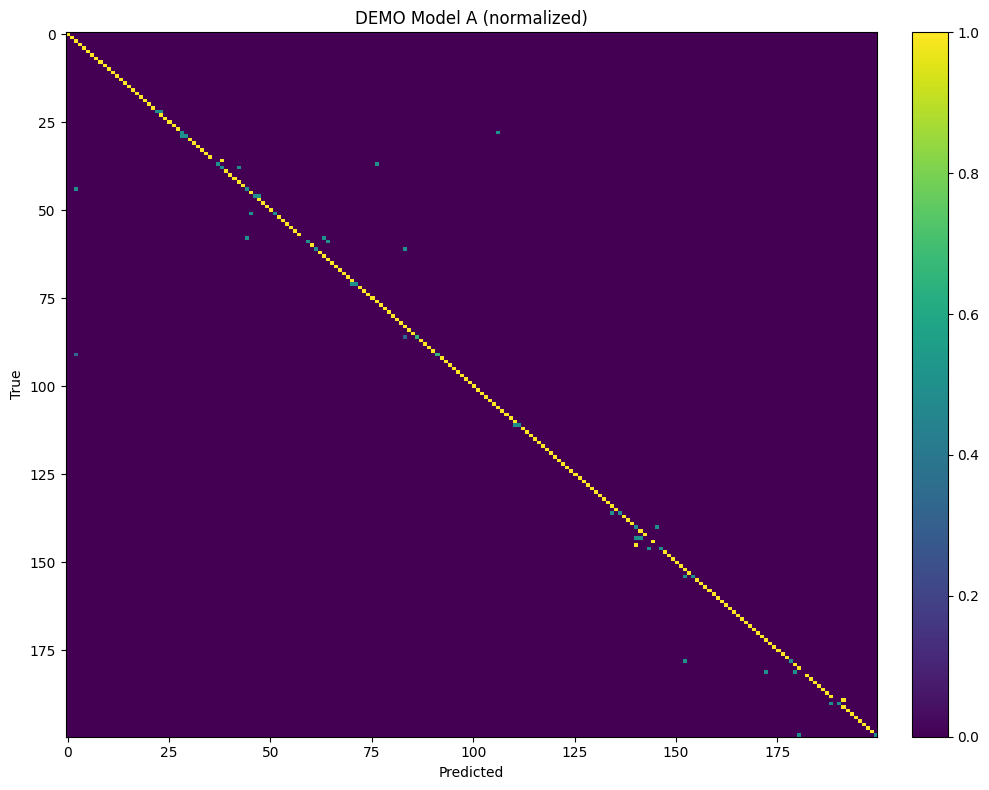


=== DEMO Model B ===
Accuracy         : 0.5323
Precision (macro): 0.5502
Recall (macro)   : 0.5325
F1 (macro)       : 0.5116


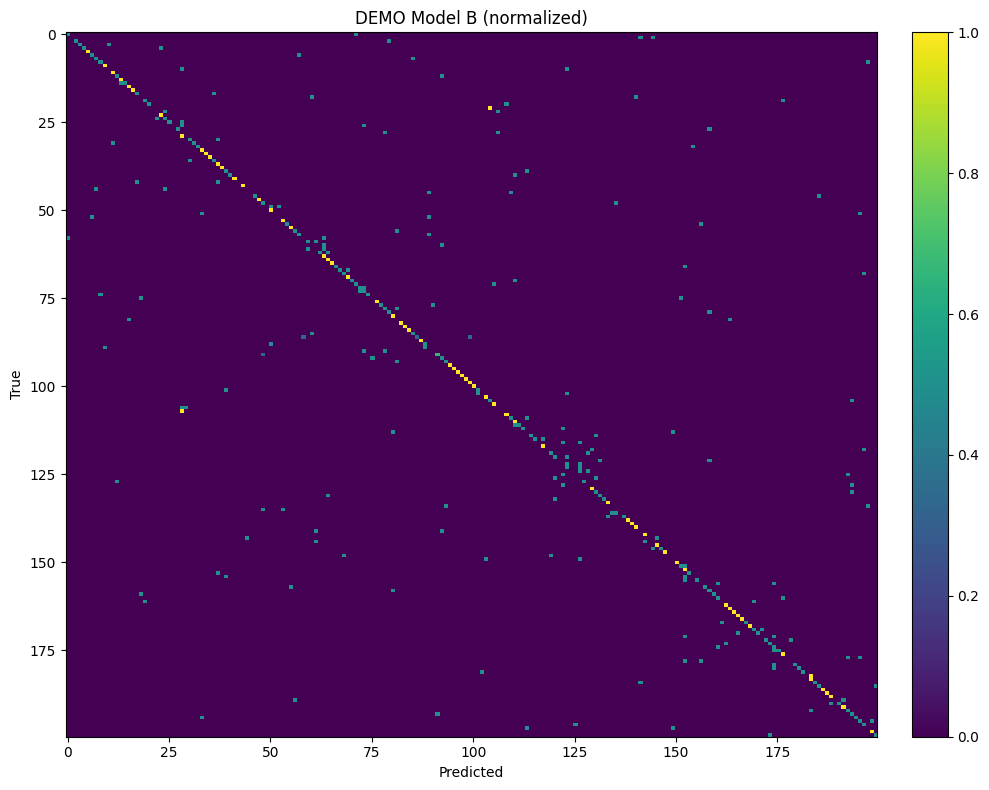

In [45]:
# Demo Images Directory
DEMO_IMAGES_DIR = Path("/content/drive/MyDrive/Deep Learning Assignment Final/Part 2/Test")

# Check if the demo images directory is set
if DEMO_IMAGES_DIR is None:
    print("Set DEMO_IMAGES_DIR, then re-run this cell.")
else:
    # List images and labels from subfolders
    image_paths, class_labels = list_images_recursive(DEMO_IMAGES_DIR)

    if not image_paths:
        raise FileNotFoundError(f"No images found in: {DEMO_IMAGES_DIR}")

    # Create a mapping from class labels to indices (class_to_idx)
    class_names = sorted(set(class_labels))
    class_to_idx = {class_name: idx for idx, class_name in enumerate(class_names)}

    # Create demo transforms for models
    demo_tfm_A = tfm_A  # Assuming 'tfm_A' is defined elsewhere
    demo_tfm_B = tfm_B  # Assuming 'tfm_B' is defined elsewhere

    # Datasets and DataLoaders
    dsA = DemoImagesDataset(image_paths, class_labels, demo_tfm_A, class_to_idx)
    dsB = DemoImagesDataset(image_paths, class_labels, demo_tfm_B, class_to_idx)

    dlA = DataLoader(dsA, batch_size=32, shuffle=False, num_workers=2, pin_memory=torch.cuda.is_available())
    dlB = DataLoader(dsB, batch_size=128, shuffle=False, num_workers=2, pin_memory=torch.cuda.is_available())

    # Run Inference for both models
    yA_pred, yA_true, pathsA = run_demo_inference(model_a, "A", dlA)
    yB_pred, yB_true, pathsB = run_demo_inference(model_b, "B", dlB)

    # Save predictions to CSV
    tag = now_tag("DEMO")

    outA = ART_DIR / f"{tag}_ModelA_predictions.csv"
    outB = ART_DIR / f"{tag}_ModelB_predictions.csv"

    pd.DataFrame({
        "path": pathsA,
        "pred_id": yA_pred.astype(int),
        "pred_name": [class_index_to_name.get(int(i), str(int(i))) for i in yA_pred],
    }).to_csv(outA, index=False)

    pd.DataFrame({
        "path": pathsB,
        "pred_id": yB_pred.astype(int),
        "pred_name": [class_index_to_name.get(int(i), str(int(i))) for i in yB_pred],
    }).to_csv(outB, index=False)

    print("Saved demo predictions:")
    print("-", outA.name)
    print("-", outB.name)

    # Compute and save confusion matrix and metrics
    if yA_true is not None:
        mA = compute_basic_metrics(yA_true, yA_pred, NUM_CLASSES)
        print_metrics_block("DEMO Model A", mA)
        np.save(ART_DIR / f"{tag}_ModelA_cm.npy", mA["confusion_matrix"])
        save_confusion_matrix_plot(mA["confusion_matrix"], "DEMO Model A (normalized)", ART_DIR / f"{tag}_ModelA_cm.png", True)
        write_json(ART_DIR / f"{tag}_ModelA_metrics.json", {k:v for k,v in mA.items() if k != "confusion_matrix"})

    if yB_true is not None:
        mB = compute_basic_metrics(yB_true, yB_pred, NUM_CLASSES)
        print_metrics_block("DEMO Model B", mB)
        np.save(ART_DIR / f"{tag}_ModelB_cm.npy", mB["confusion_matrix"])
        save_confusion_matrix_plot(mB["confusion_matrix"], "DEMO Model B (normalized)", ART_DIR / f"{tag}_ModelB_cm.png", True)
        write_json(ART_DIR / f"{tag}_ModelB_metrics.json", {k:v for k,v in mB.items() if k != "confusion_matrix"})